In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
data=pd.read_table(r'C:\Data_Set\P176.txt')

In [3]:

data.head()

,X,Y
0,294,30
1,247,32
2,267,37
3,358,44
4,423,47


In [4]:
data.shape

(27, 2)

In [5]:
n=data.shape[0]
print(n)

27


In [6]:
x=data['X']

In [7]:
y=data['Y']

In [8]:
x.shape

(27,)

# Calculate intercept beta_0

In [9]:
beta_1=(1/n*np.sum(x)*np.sum(y)-np.sum(x*y))/(1/n*(np.sum(x)**2)-np.sum(x*x))
print(beta_1)

0.10536109357806464


# Calculate intercept beta_0

In [10]:
beta_0=1/n*np.sum(y)-beta_1/n*np.sum(x)
print(beta_0)


14.44805857961758


# The equation of linear regression is y=14.4480+0.10536*x

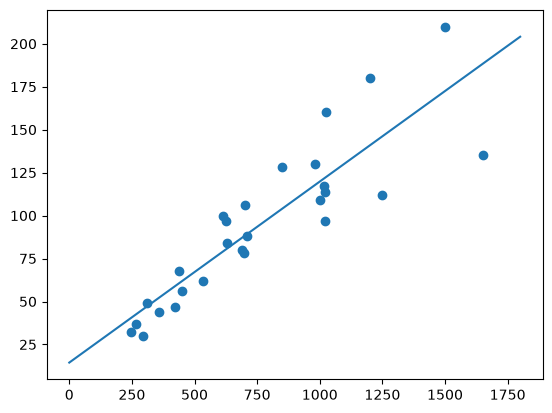

In [11]:

plt.scatter(x,y)
x1=np.linspace(0,1800,500)
y1=beta_0+beta_1*x1
plt.plot(x1,y1,'-')
plt.show()

# Fit a linear regression model for multiple variable


In [12]:
X=pd.read_csv('C:\Data_Set\LR_X.csv')
Y=pd.read_csv('C:\Data_Set\LR_Y.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\121so\AppData\Local\Temp\ipykernel_16304\2948252135.py:1: SyntaxWarning: invalid escape sequence '\D'
  X=pd.read_csv('C:\Data_Set\LR_X.csv')
C:\Users\121so\AppData\Local\Temp\ipykernel_16304\2948252135.py:2: SyntaxWarning: invalid escape sequence '\D'
  Y=pd.read_csv('C:\Data_Set\LR_Y.csv')


# Calculate shape of X and Y

In [13]:
X.shape

(1000, 3)

In [14]:
Y.shape

(1000, 1)

In [15]:
X.head()

,X1,X2,X3
0,0.26,0.08,0.28
1,0.26,0.52,0.01
2,0.85,0.60,0.14
3,0.94,0.22,0.48
4,0.53,0.05,0.76


In [16]:
Y.head()

,Y
0,1.472
1,1.802
2,1.548
3,1.390
4,2.141


# Check range of the data

In [17]:
X.describe()

,X1,X2,X3
count,1000.000000,1000.000000,1000.000000
mean,0.493360,0.501480,0.493320
std,0.287477,0.287708,0.285183
min,0.000000,0.000000,0.000000
25%,0.250000,0.270000,0.250000
50%,0.480000,0.495000,0.490000
75%,0.740000,0.750000,0.730000
max,1.000000,1.000000,1.000000


# Append a column with the independent variable X

In [18]:
ones=np.ones((1000,1))

In [20]:
ones.shape

(1000, 1)

In [21]:
ones[:10]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [22]:
new_X=np.concatenate((ones,X),axis=1)

In [23]:
new_X

array([[1.  , 0.26, 0.08, 0.28],
       [1.  , 0.26, 0.52, 0.01],
       [1.  , 0.85, 0.6 , 0.14],
       ...,
       [1.  , 0.88, 0.06, 0.33],
       [1.  , 0.28, 0.4 , 0.41],
       [1.  , 0.94, 0.48, 0.45]], shape=(1000, 4))

In [24]:
new_X.shape

(1000, 4)

In [26]:
res1=np.linalg.inv(np.dot(np.transpose(new_X),new_X))

In [27]:
res1.shape

(4, 4)

In [28]:
res2=np.dot(np.transpose(new_X),Y)
res2.shape

(4, 1)

In [29]:
beta=np.dot(res1,res2)
print(beta)

[[ 1. ]
 [-1.2]
 [ 2.1]
 [ 2.2]]


# The equation of the linear regression is Y=1.0-1.2x1+2.1x2+2.2*x2

In [30]:
x

0      294
1      247
2      267
3      358
4      423
5      311
6      450
7      534
8      438
9      697
10     688
11     630
12     709
13     627
14     615
15     999
16    1022
17    1015
18     700
19     850
20     980
21    1025
22    1021
23    1200
24    1250
25    1500
26    1650
Name: X, dtype: int64

# Gradient Descent

In [31]:
data

,X,Y
0,294,30
1,247,32
2,267,37
3,358,44
4,423,47
5,311,49
6,450,56
7,534,62
8,438,68
9,697,78


In [32]:
x=data['X']
y=data['Y']

# Normalize your data

In [33]:
x1=(x-np.mean(x))/np.std(x)
y1=(y-np.mean(y))/np.std(y)

In [34]:
def grad_beta0(beta0,beta1,x1,y1):
    n=len(x1)
    res=0
    for i in range(n):
        res+=(y1[i]-beta0-beta1*x1[i])
    grad_b0=-2/float(n)*res
    #print(grad_b0)
    return grad_b0

In [35]:
def grad_beta1(beta0,beta1,x1,y1):
    n=len(x1)
    res=0
    for i in range(n):
        res+=x1[i]*(y1[i]-beta0-beta1*x1[i])
    grad_b1=-2/float(n)*res
    #print(grad_b1)
    return grad_b1

In [36]:
def gradient_descent(x,y):
    beta0=0
    beta1=0
    lr=0.1
    epochs=1
    while epochs<=100:
        up_b0=grad_beta0(beta0,beta1,x1,y1)
        up_b1=grad_beta1(beta0,beta1,x1,y1)
        beta0=beta0-lr*up_b0
        beta1=beta1-lr*up_b1
        y_hat=beta0+beta1*x
        plt.plot(x,y_hat)
        epochs+=1
    return beta0,beta1

-5.468876380560958e-17 0.8808360812820623


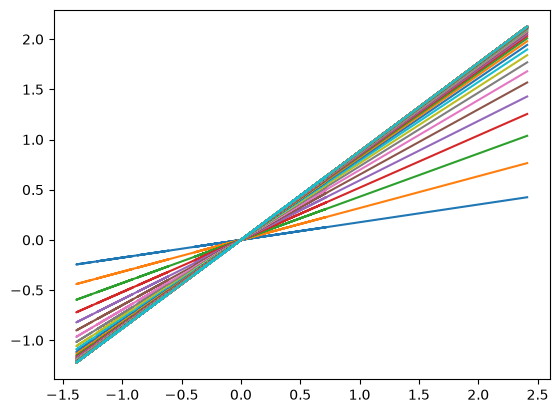

In [37]:
b0,b1=gradient_descent(x1,y1)
print(b0,b1)

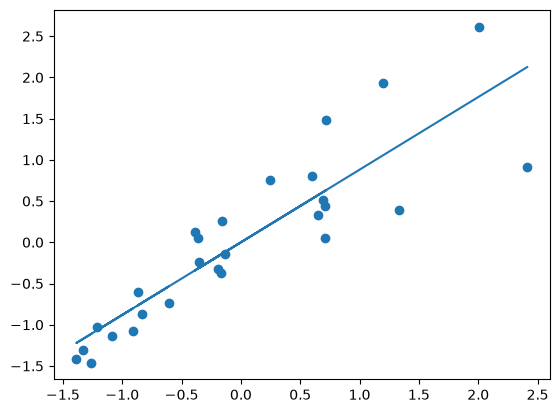

In [38]:

plt.scatter(x1,y1)
#x2=np.linspace(-3,3,500)
y2=b0+b1*x1
plt.plot(x1,y2,'-')
plt.show()

# use array operation

In [39]:
def gradient_descent1(x,y):
    beta0=0
    beta1=0
    lr=0.01
    epochs=1
    n=float(len(x))
    while epochs<=1000:
        y_hat=beta0+beta1*x
        up_b0=-(2/n)*np.sum(y-y_hat)
        up_b1=-(2/n)*np.sum(x*(y-y_hat))
        beta0=beta0-lr*up_b0
        beta1=beta1-lr*up_b1
        epochs+=1
    return beta0,beta1

In [40]:
b0,b1=gradient_descent1(x1,y1)
print(b0,b1)

-5.5017718775868785e-17 0.8808360799790734


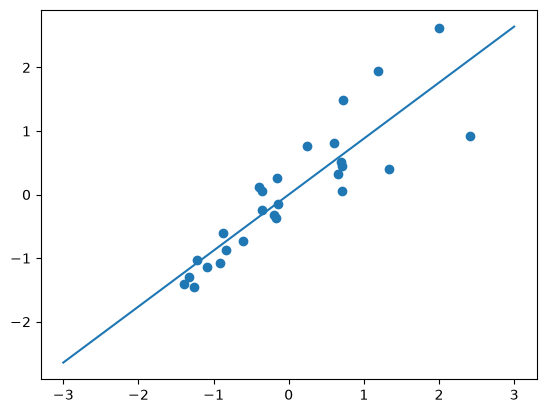

In [41]:
plt.scatter(x1,y1)
x2=np.linspace(-3,3,500)
y2=b0+b1*x2
plt.plot(x2,y2,'-')
plt.show()